Session 3 - Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/online_retail_cleaned.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceDay,InvoiceHour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,InvoiceDay,InvoiceHour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12-01,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12-01,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12-01,8,Wednesday


------------------------------------------------------------------------------------------

Overall business overview

Tasks
1. Calculate total revenue
2. Calculate the total number of transactions
3. Calculate the total number of unique customers
4. Calculate the total quantity of all sold items

In [4]:
total_revenue = df["Revenue"].sum()
total_transactions = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_quantity = df["Quantity"].sum()

print("Total Revenue:", round(total_revenue, 2))
print("Total Transactions:", total_transactions)
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)

Total Revenue: 8911407.9
Total Transactions: 18532
Total Customers: 4338
Total Quantity Sold: 5167812


From the calculations above:

Total revenue in the dataset is 8911407.9

The cleaned dataset represents 18532 completed transactions from 4338 unique customers and a total of 5167812 quantities of items sold.

------------------------------------------------------------------------------------------

Revenue over time calculations

Tasks

1. Calculate total revenue and group by month
2. Plot the revenue against months and understand the trend

In [6]:
monthly_revenue = df.groupby("InvoiceMonth")["Revenue"].sum().sort_index()
print(monthly_revenue)

InvoiceMonth
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Name: Revenue, dtype: float64


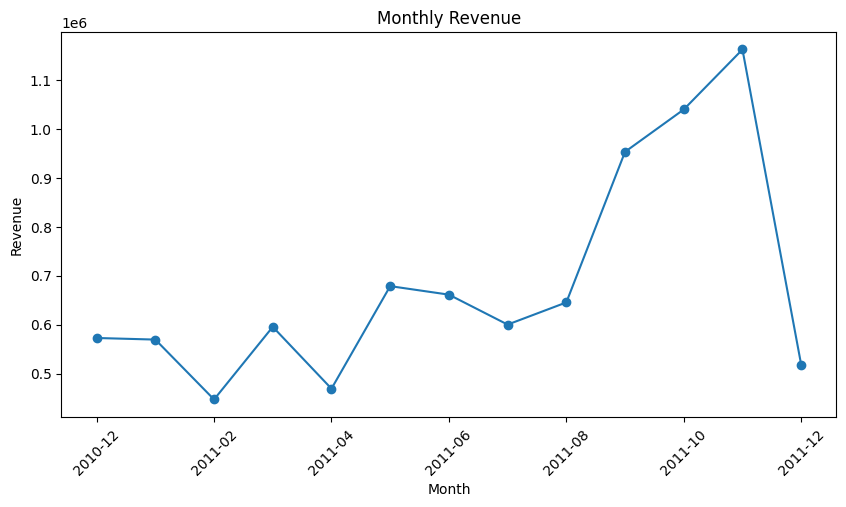

In [9]:
monthly_revenue.plot(figsize=(10,5), marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Based of the chart above we can explain a few trends that occured throughout the year

1. The revenue was the highest in November and the lowest in February
2. There was a massive spike in revenue from August to September marking the start of the festival and holiday season
3. Surprisingly however, There was a massive drop in revenue from November( where the revenue peaked) to december, which can be either explained by less inventory or people already finishing their holiday shoppping by november


Suggestions to retailer

The retailer needs a stronger inventory plan throughout the year, stock pilling items throughout spring and summer and being ready for the increase in orders as soon as september hits, and also not running out of inventory during the last month of the year which arguably can have an even higher revenue number than november.

------------------------------------------------------------------------------------------

Top countries

Tasks
1. Calculate the revenue by country
2. Calculate the transaction count by country
3. Plot revenue for the top 10 countries and understand the trend

In [11]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
print(country_revenue.head(20))

Country
United Kingdom     7308391.554
Netherlands         285446.340
EIRE                265545.900
Germany             228867.140
France              209024.050
Australia           138521.310
Spain                61577.110
Switzerland          56443.950
Belgium              41196.340
Sweden               38378.330
Japan                37416.370
Norway               36165.440
Portugal             33439.890
Finland              22546.080
Singapore            21279.290
Channel Islands      20450.440
Denmark              18955.340
Italy                17483.240
Cyprus               13590.380
Austria              10198.680
Name: Revenue, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

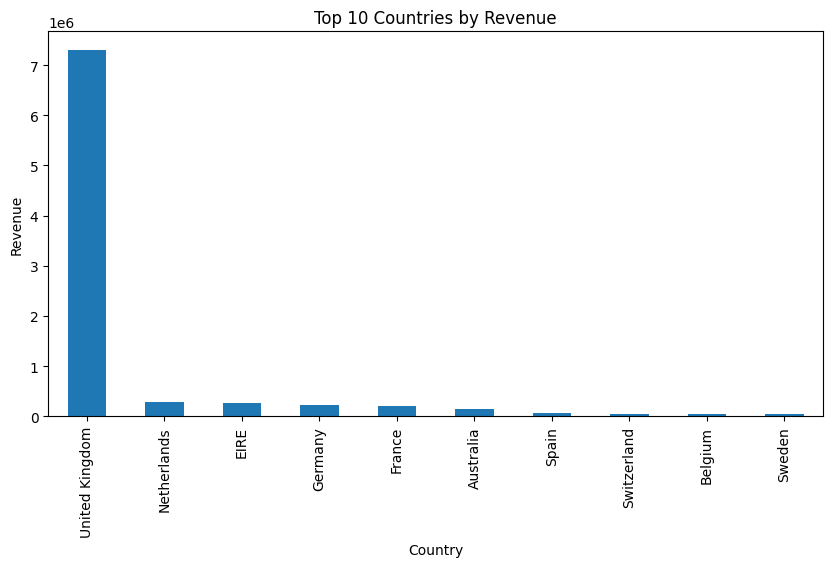

In [12]:
country_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show

In [13]:
country_customers = df.groupby("Country")["CustomerID"].nunique().sort_values(ascending=False)
print(country_customers.head(10))

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

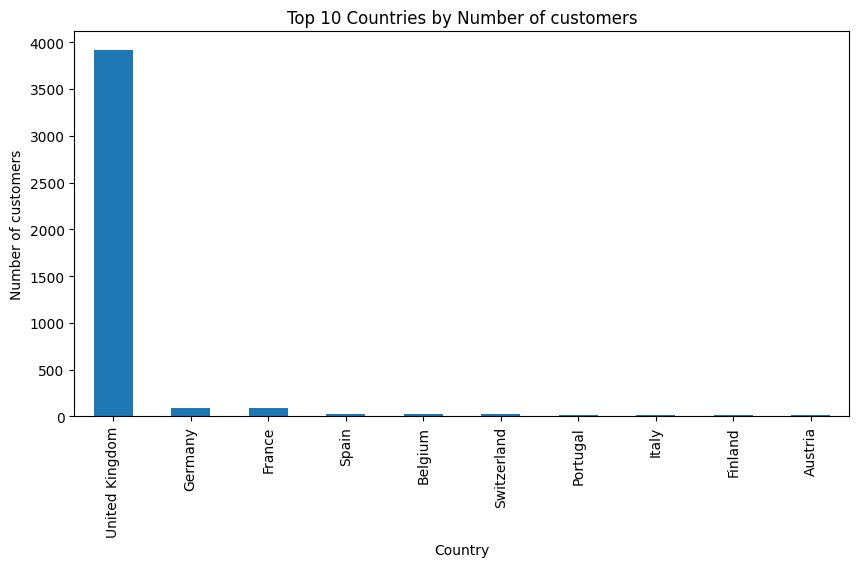

In [14]:
country_customers.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Number of customers")
plt.xlabel("Country")
plt.ylabel("Number of customers")
plt.show

Based of the graphs above we can definitively say that UK has the highest revenue yield and the most number of customers, suggesting the retailer's sales are heavily concentrated in its domestic market. Apart from this Netherlands and ERIE had the second highest revenue however they werent in the top 10 for the most number of customers signifying that they had some pretty large orders from not many customers.

------------------------------------------------------------------------------------------

Top Products

Tasks
1. Calculate the top products by revenue
2. Calculate the top products by quantity sold


In [16]:
product_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
product_revenue.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

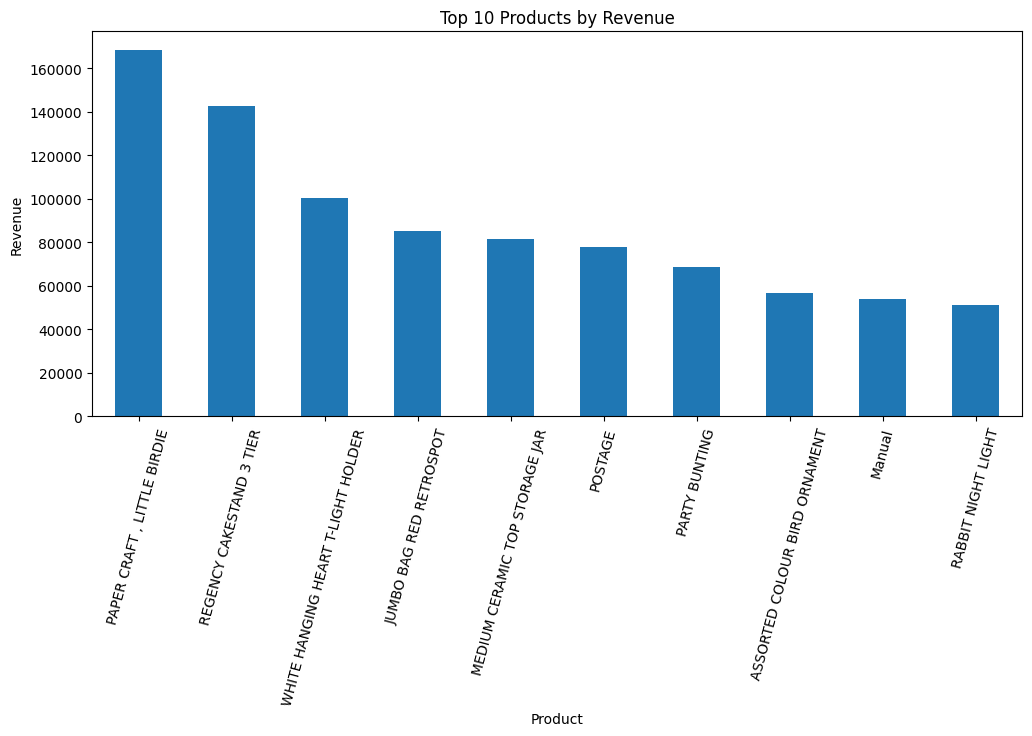

In [17]:
product_revenue.head(10).plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=75)
plt.show()

In [18]:
product_quantity = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

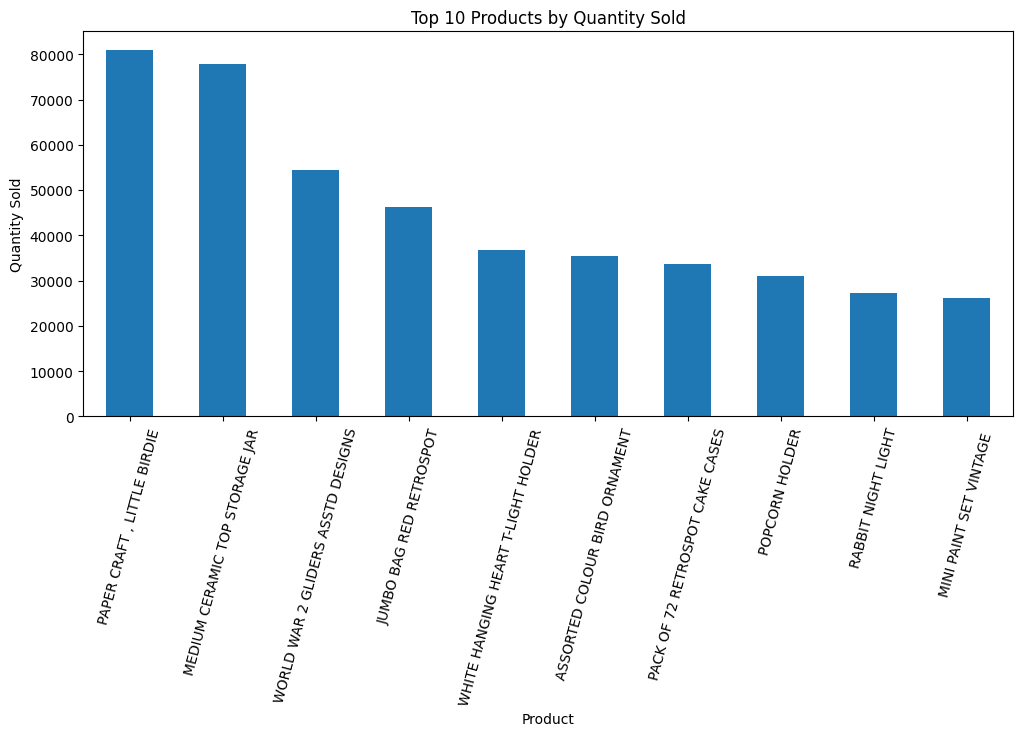

In [19]:
product_quantity.head(10).plot(kind="bar", figsize=(12,5))
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.show()

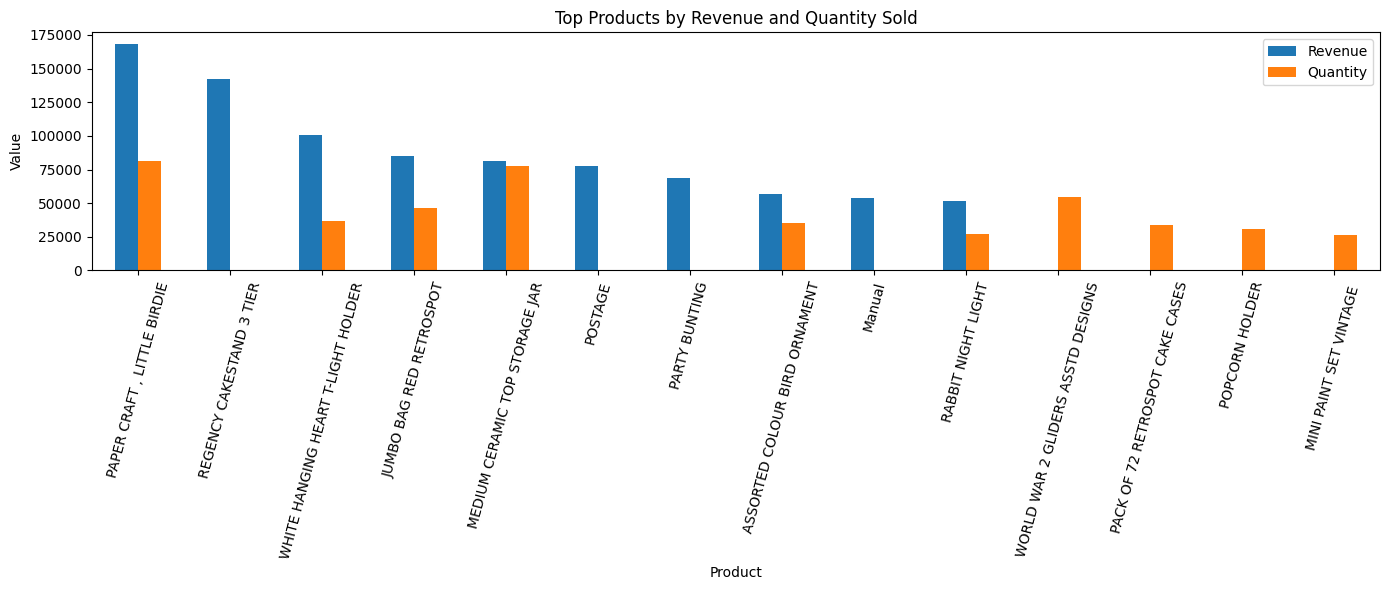

In [20]:
comparison = pd.concat([product_revenue.head(10), product_quantity.head(10)], axis=1)
comparison.columns = ["Revenue", "Quantity"]
comparison = comparison.fillna(0)

comparison.plot(kind="bar", figsize=(14,6))
plt.title("Top Products by Revenue and Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Value")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

This last graph shows us the comparison of the top 10 products based of revenue and quantity sold. Based off this we can suggest that the retailer can increase the price of the goods whose quantity sold are in the top 10 but not the revenue to maximize their profit on that particular item, and do the opposite by reducing the price of the products with the top 10 revenue and not quantities sold. By taking these measures the retailer can try and change prices for the products and find what price of each product will maximize their profit.

Apart from this we can tell that 
1. Paper craft, little bridge is by far the best item in both revenue and quantities sold.
2. Regency cakestand 3 tier brings in the second most revenue but is not in the top ten of the quantities of items sold, hence the retailer should decrease the price to maximize its profit ( same for postage, party bunting, and manual but the margin for decreasing the price will be lower).
3. Medium ceramic top storage jar has 2nd highest quantities sold but only fifth in revenue hence retailer should increase the price of it to increase its profit (Same principle for World war 2 gliders ASSTD designs, Pack of 72 retrospot cake cases, popcorn holders, and mini paint set vintage).

------------------------------------------------------------------------------------------

Top Customers

Tasks
1. Identify the top customers based on revenue
2. Calculate total orders per customer
3. Calculate the average spend per customer

In [22]:
customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

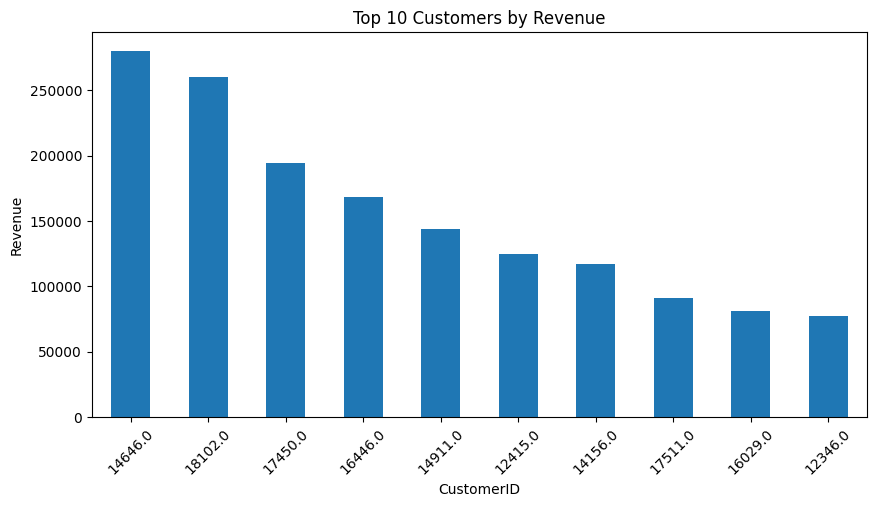

In [23]:
customer_revenue.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [24]:
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False)
customer_orders.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

In [25]:
avg_revenue_per_customer = df.groupby("CustomerID")["Revenue"].sum().mean()
print("Average Revenue per Customer:", round(avg_revenue_per_customer, 2))

Average Revenue per Customer: 2054.27


Based off the above calculations and the graph, we can see that some customers (14646, 18102, etc.) are heavy spenders whereas the average revenue per customer is alot less compared to these heavy revenue spenders.

------------------------------------------------------------------------------------------------------